In [3]:
# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

In [4]:
# 데이터 가져오기
housing = fetch_california_housing()

# 입력 변수 : feature(평균소득, 방 개수 등등)  <-- 독립변수
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# 타겟 변수 : 집 값  <-- 종속 변수
y = pd.Series(housing.target, name="target")

print("데이터 shape : ", X.shape)

데이터 shape :  (20640, 8)


In [5]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [6]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: target, Length: 20640, dtype: float64

In [7]:
# 데이터 전처리
print("\n [결측치 확인]")
print(X.isnull().sum())


 [결측치 확인]
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [8]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# 모델 생성 및 학습 (LightGBM 모델)
model = LGBMRegressor(
    n_estimators=200,   # 트리 개수
    learning_rate=0.08, # 학습 속도
    max_depth=-1,       # 트리 깊이 제한 없음
    num_leaves=31,      # 리프 개수 (복잡도)
    subsample=0.7,      # 데이터 일부 사용 (과적합 방지)
    random_state=42     # 결과 고정
)

# 모델 학습
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.08
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [10]:
# 예측 수행
y_pred = model.predict(X_test)

In [15]:
# 모델 성능 평가
# MAE: 평균 절대 오차
mae = mean_absolute_error(y_test, y_pred)

# RMSE: 평균 제곱 오차의 루트
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2: 모델 설명력 (1에 가까울수록 좋음)
r2 = r2_score(y_test, y_pred)

# 결과 출력
print("\n[LightGBM 성능]")
print(f"MAE : {mae}")
print(f"RMSE : {rmse}")
print(f"R2 : {r2}")


[LightGBM 성능]
MAE : 0.29716850335541917
RMSE : 0.4493265028261359
R2 : 0.8459303091673032


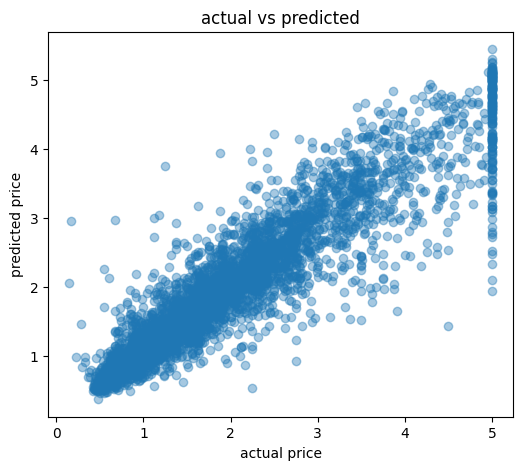

In [20]:
# 성능 시각화
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.4)  # alpha: 점 투명도 (0~1, 낮을수록 투명 → 겹침 확인용)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual vs predicted")

plt.show()

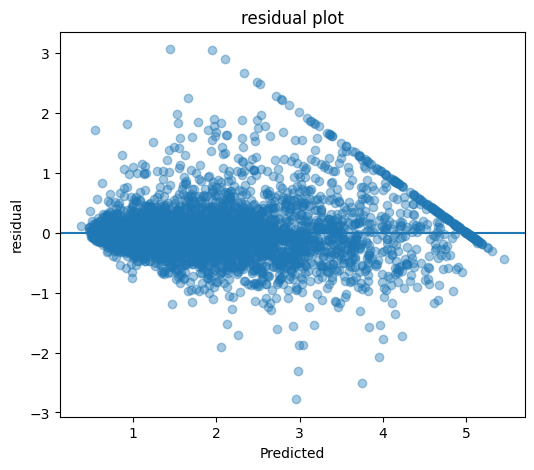

In [19]:
# residual: 실제값 - 예측값 (오차)
residuals = y_test - y_pred
plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.4)

# 기준선 (오차 0)
plt.axhline(0)

plt.xlabel("Predicted")
plt.ylabel("residual")
plt.title("residual plot")

plt.show()

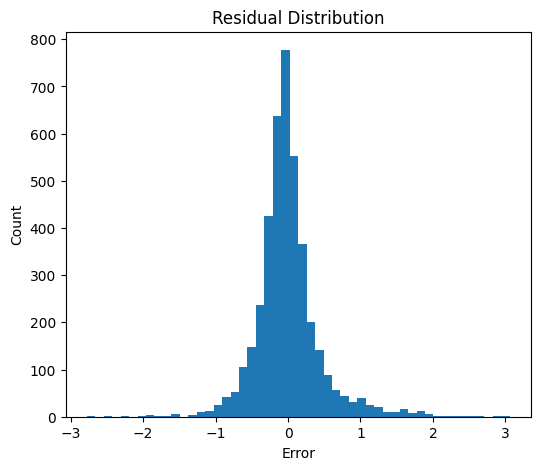

In [17]:
plt.figure(figsize=(6,5))

plt.hist(residuals, bins=50)
plt.xlabel("Error")
plt.ylabel("Count")

plt.title("Residual Distribution")

plt.show()

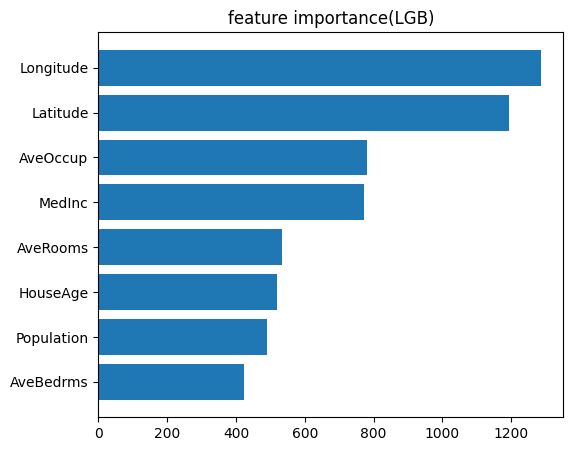

In [22]:
# feature importance
importance = model.feature_importances_

# 중요도 정렬
indices = np.argsort(importance)
plt.figure(figsize=(6,5))

# 가로 막대 그래프
plt.barh(range(len(indices)), importance[indices])   # barh: 가로 막대 그래프 (importance 값을 길이로 표현)
plt.yticks(range(len(indices)), X.columns[indices])  # yticks: 각 막대 위치에 feature 이름 붙이기

plt.title("feature importance(LGB)")
plt.show()

In [24]:
# 모델 예측
sample_data = X_test.iloc[:5]            # 테스트 데이터 중 앞 5개 샘플 선택

# 예측 수행
sample_pred = model.predict(sample_data)  # 선택한 샘플에 대한 예측값 생성

print("\n [샘플 예측 결과]")
for i, pred in enumerate(sample_pred):   # enumerate: (인덱스, 값) 함께 꺼냄
    print(f"{i+1}번째 샘플 예측 집값: {pred:.4f}")  # 소수점 4자리까지 출력

print("\n[실제값]")
print(y_test.iloc[:5].values)            # 실제값 (numpy 배열 형태로 출력)


 [샘플 예측 결과]
1번째 샘플 예측 집값: 0.5947
2번째 샘플 예측 집값: 0.9746
3번째 샘플 예측 집값: 4.7610
4번째 샘플 예측 집값: 2.5062
5번째 샘플 예측 집값: 2.4046

[실제값]
[0.477   0.458   5.00001 2.186   2.78   ]


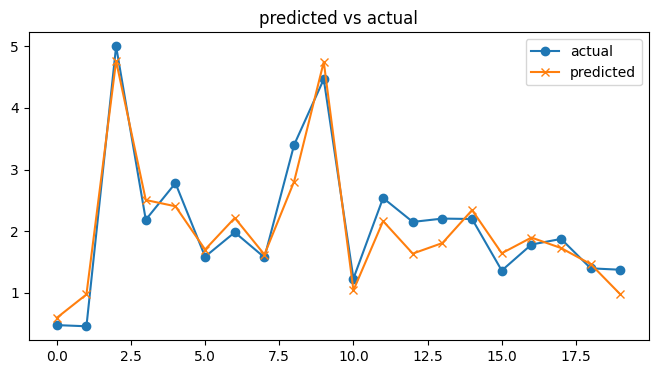

In [25]:
# 예측 결과 시각화
plt.figure(figsize=(8,4))
plt.plot(y_test.iloc[:20].values, label="actual", marker="o")   # 실제값
plt.plot(model.predict(X_test.iloc[:20]), label="predicted", marker="x")

plt.title("predicted vs actual")
plt.legend()
plt.show()